In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Import the three classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Import evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix


In [11]:
# Load dataset
df = pd.read_excel("/content/customer_reatil.csv.xlsx")

# Print the first few rows to verify data
print(df.head())

# Drop rows containing missing values (Data Cleaning)
df = df.dropna()

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [12]:
# Initialize the LabelEncoder
encoder = LabelEncoder()

# Create a new encoded column for the target data
df['Country_Encoded'] = encoder.fit_transform(df['Country'])

# Print the unique encoded values to confirm it worked
print("Encoded Country Values Sample:")
print(df[['Country', 'Country_Encoded']].head(10))

Encoded Country Values Sample:
          Country  Country_Encoded
0  United Kingdom               35
1  United Kingdom               35
2  United Kingdom               35
3  United Kingdom               35
4  United Kingdom               35
5  United Kingdom               35
6  United Kingdom               35
7  United Kingdom               35
8  United Kingdom               35
9  United Kingdom               35


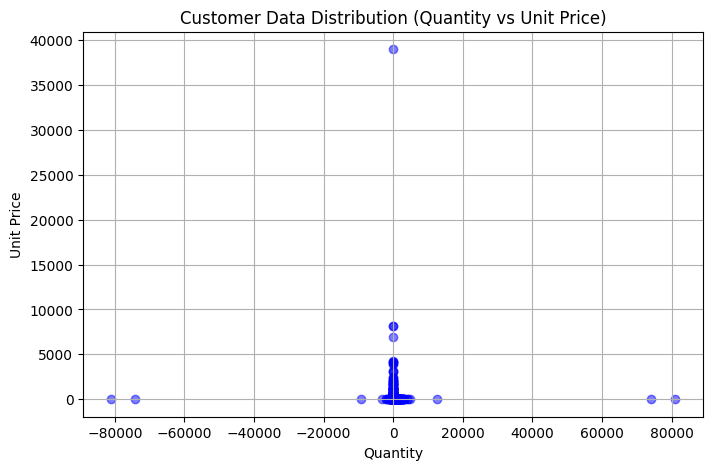

In [13]:
# Create a scatter plot for Quantity vs UnitPrice
plt.figure(figsize=(8, 5))
plt.scatter(df['Quantity'], df['UnitPrice'], alpha=0.5, color='blue')
plt.title('Customer Data Distribution (Quantity vs Unit Price)')
plt.xlabel('Quantity')
plt.ylabel('Unit Price')
plt.grid(True)
plt.show()

In [14]:
# Select features (Inputs) and target (Output label)
X = df[['Quantity', 'UnitPrice']]
y = df['Country_Encoded']

# Split the dataset into an 80% training set and 20% testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shape of the datasets to confirm the split
print("Data successfully split into Train and Test sets!")
print(f"Total Training rows (X_train): {X_train.shape[0]}")
print(f"Total Testing rows (X_test): {X_test.shape[0]}")

Data successfully split into Train and Test sets!
Total Training rows (X_train): 325463
Total Testing rows (X_test): 81366


In [15]:
print("--- Training Logistic Regression Model ---")

# Initialize the model
log_model = LogisticRegression()

# Train the model using training data
log_model.fit(X_train, y_train)

# Make predictions on testing data
log_pred = log_model.predict(X_test)

# Calculate Accuracy and Confusion Matrix
log_accuracy = accuracy_score(y_test, log_pred)
log_cm = confusion_matrix(y_test, log_pred)

# Display the performance results
print(f"Logistic Regression Accuracy: {log_accuracy * 100:.2f}%")
print("Confusion Matrix:\n", log_cm)

--- Training Logistic Regression Model ---
Logistic Regression Accuracy: 88.97%
Confusion Matrix:
 [[    0     0     0 ...     0   229     0]
 [    0     0     0 ...     0    78     0]
 [    0     0     0 ...     0     5     0]
 ...
 [    0     0     0 ...     0    13     0]
 [    7     0     0 ...     0 72395     0]
 [    0     0     0 ...     0    43     0]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
print("\n--- Training Decision Tree Classifier Model ---")

# Initialize the model
dt_model = DecisionTreeClassifier()

# Train the model using training data
dt_model.fit(X_train, y_train)

# Make predictions on testing data
dt_pred = dt_model.predict(X_test)

# Calculate Accuracy and Confusion Matrix
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_cm = confusion_matrix(y_test, dt_pred)

# Display the performance results
print(f"Decision Tree Accuracy: {dt_accuracy * 100:.2f}%")
print("Confusion Matrix:\n", dt_cm)


--- Training Decision Tree Classifier Model ---
Decision Tree Accuracy: 89.03%
Confusion Matrix:
 [[   13     0     0 ...     0   197     0]
 [    0     0     0 ...     0    75     0]
 [    0     0     0 ...     0     5     0]
 ...
 [    0     0     0 ...     0    13     0]
 [   20     0     0 ...     1 72220     0]
 [    0     0     0 ...     0    43     0]]


In [17]:
print("\n--- Training K-Nearest Neighbors (KNN) Model ---")

# Initialize the model (Setting k=5 neighbors)
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model using training data
knn_model.fit(X_train, y_train)

# Make predictions on testing data
knn_pred = knn_model.predict(X_test)

# Calculate Accuracy and Confusion Matrix
knn_accuracy = accuracy_score(y_test, knn_pred)
knn_cm = confusion_matrix(y_test, knn_pred)

# Display the performance results
print(f"KNN Accuracy: {knn_accuracy * 100:.2f}%")
print("Confusion Matrix:\n", knn_cm)


--- Training K-Nearest Neighbors (KNN) Model ---
KNN Accuracy: 88.42%
Confusion Matrix:
 [[   25     0     0 ...     0   181     0]
 [    0     0     0 ...     0    75     0]
 [    0     0     0 ...     0     5     0]
 ...
 [    0     0     0 ...     0    12     0]
 [   41     2     0 ...     0 71636     0]
 [    0     0     0 ...     0    43     0]]


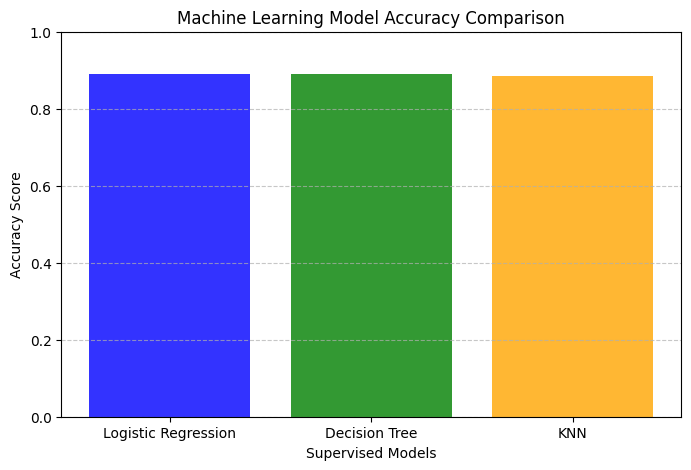

In [18]:
# Lists containing the model names and their respective calculated accuracies
models = ['Logistic Regression', 'Decision Tree', 'KNN']
accuracies = [log_accuracy, dt_accuracy, knn_accuracy]

# Plotting the bar graph
plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['blue', 'green', 'orange'], alpha=0.8)
plt.ylim(0, 1.0)  # Sets the graph bounds from 0% to 100%
plt.title('Machine Learning Model Accuracy Comparison')
plt.xlabel('Supervised Models')
plt.ylabel('Accuracy Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the visualization graph
plt.show()